# Coarse Parameter Optimization: Maximize Score Separation

Grid search over the 3-stage model parameters (sigma0, sigma1, sigma2, t_step)
to find which combination maximizes the separation between repeat and non-repeat
score distributions. Uses AUROC as the separation metric.

This is intentionally coarse and fast — runs only 1 seed on a subset of experiments.

In [1]:
import os
import sys
import json
import pickle
import re
import random
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from collections import defaultdict
from itertools import product
from scipy.stats import spearmanr, pearsonr, norm

# ── project paths ──
sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from encoders import *
from utls.loading import load_results_with_exclusion_no_dropping
from utls.runners_v2 import run_experiment_scores_itemwise, make_noise_schedule
from utls.roc_utils import roc_from_arrays, roc_from_arrays_with_threshold
from utls.analysis_helpers import auroc_to_dprime, roc_for_isi
from utls.runners_utils import (
    compute_human_curve,
    build_encoder,
    encode_stimuli,
    refresh_unused_batch,
)
from utls.data_loading import (
    TASKS_SINGLE, SEQS_PATHS, HR_TASK_NAMES,
    sequences_path_single,
)

## Configuration

In [7]:
# ── Which task? ──
# 0 = Industrial & Nature,  1 = Globalized Music,  2 = Auditory Textures
which_task = 0
which_isi  = 16

# ── Fixed model settings ──
encoder_name = "resnet50"
layer_name   = "layer4"
noise_mode   = "three-regime"
metric       = "cosine"
pc_dims      = None           # only for texture_pca

num_grids = 6

# ── Parameter grid (coarse) ──
sigma0_grid = np.round(np.geomspace(1.0, 15.0, num_grids), 2).tolist()
sigma1_grid = np.round(np.geomspace(0.1, 5.0, num_grids), 2).tolist()
sigma2_grid = np.round(np.geomspace(0.001, 0.5, num_grids), 4).tolist()
t_step_grid = [5]

# ── How many experiments to use (subset for speed) ──
max_experiments = 16    # set to None to use all
n_seeds         = 1    # 1 is fine for coarse search

# ── Output ──
save_dir = "/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/fits/coarse_grid_separation"

total_combos = len(sigma0_grid) * len(sigma1_grid) * len(sigma2_grid) * len(t_step_grid)
print(f"Grid: {len(sigma0_grid)} x {len(sigma1_grid)} x {len(sigma2_grid)} x {len(t_step_grid)} = {total_combos} combinations")
print(f"sigma0: {sigma0_grid}")
print(f"sigma1: {sigma1_grid}")
print(f"sigma2: {sigma2_grid}")
print(f"t_step: {t_step_grid}")
print(f"\nMax experiments: {max_experiments}")
print(f"Seeds per combo: {n_seeds}")

Grid: 6 x 6 x 6 x 1 = 216 combinations
sigma0: [1.0, 1.72, 2.95, 5.08, 8.73, 15.0]
sigma1: [0.1, 0.22, 0.48, 1.05, 2.29, 5.0]
sigma2: [0.001, 0.0035, 0.012, 0.0416, 0.1443, 0.5]
t_step: [5]

Max experiments: 16
Seeds per combo: 1


## Derived Config & Task Setup

In [3]:
tasks_map = {
    0: "ind-nature-len120",
    1: "global-music-len120",
    2: "atexts-len120",
    3: "nhs-region-len120",
}

task_name    = tasks_map[which_task]
hr_task_name = HR_TASK_NAMES.get(task_name, task_name)
seq_path_key = SEQS_PATHS[task_name]

base_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{seq_path_key}/sequences/isi_{which_isi}/len120/"

print(f"Task: {task_name} ({hr_task_name})")
print(f"ISI:  {which_isi}")

Task: ind-nature-len120 (Industrial and Nature)
ISI:  16


## Load Single-ISI Human Data

In [4]:
results_dir = (
    f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/"
    f"isi_{which_isi}/{task_name}"
)

exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
    results_dir,
    min_dprime=2, min_trials=120, skip_len60=True,
    verbose=False, return_skipped=True,
)

# deduplicate: one participant per sequence
seq_to_indices = defaultdict(list)
for i, s in enumerate(seqs):
    seq_to_indices[s].append(i)
keep = [random.choice(idxs) for idxs in seq_to_indices.values()]
exps   = [exps[i]   for i in keep]
seqs   = [seqs[i]   for i in keep]
fnames = [fnames[i] for i in keep]

print(f"Loaded {len(exps)} participants (after dedup)")

# build experiment_list and name_to_idx
experiment_list = []
seq_dir   = base_path
stim_base = "/".join(seq_dir.split("/")[:-3])

for seq in seqs:
    with open(seq_dir + seq, "r") as f:
        data = json.load(f)
    stim_files = [stim_base + "/" + s for s in data["filenames_order"]]
    experiment_list.append(stim_files)

all_files   = sorted({fn for seq in experiment_list for fn in seq})
name_to_idx = {fn: i for i, fn in enumerate(all_files)}

# subsample experiments for speed
if max_experiments is not None and len(experiment_list) > max_experiments:
    rng = random.Random(42)
    experiment_list = rng.sample(experiment_list, max_experiments)
    # rebuild all_files and name_to_idx for the subset
    all_files   = sorted({fn for seq in experiment_list for fn in seq})
    name_to_idx = {fn: i for i, fn in enumerate(all_files)}

print(f"Using {len(experiment_list)} experiments, {len(all_files)} unique stimuli")

Loaded 75 participants (after dedup)
Using 16 experiments, 80 unique stimuli


## Build Encoder & Encode Stimuli

In [5]:
all_files_fixed = [s.replace("/sequences", "") for s in all_files]

encoder_cfg = dict(
    encoder_type    = encoder_name,
    model_name      = encoder_name,
    layer           = layer_name,
    task            = "word_speaker_audioset" if encoder_name != "texture_pca" else "audioset",
    statistics_dict = statistics_set.statistics,
    model_params    = model_params,
    pc_dims         = pc_dims,
    sr              = 20000,
    duration        = 2.0,
    rms_level       = 0.05,
    time_avg        = False,
    device          = "cuda",
)

encoder = build_encoder(encoder_cfg)
X0 = encode_stimuli(encoder, all_files_fixed)

print(f"Encoded {X0.shape[0]} stimuli, {X0.shape[1]} features")

LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoded 80 stimuli, 186368 features


## Grid Search: Maximize AUROC (Distribution Separation)

In [31]:
%%time

results = []
best_auroc = -1
best_params = None

t0 = time.time()

for combo_i, (s0, s1, s2, ts) in enumerate(
    product(sigma0_grid, sigma1_grid, sigma2_grid, t_step_grid)
):
    # skip obviously bad combos: sigma1 should be <= sigma0, sigma2 <= sigma1
    if s1 > s0 or s2 > s1:
        continue

    repeat_scores     = []
    non_repeat_scores = []

    for seed in range(n_seeds):
        run_out = run_experiment_scores_itemwise(
            sigma0     = s0,
            sigma1     = s1,
            sigma2     = s2,
            t_step     = ts,
            rate       = None,
            noise_mode = noise_mode,
            metric     = metric,
            X0         = X0,
            name_to_idx = name_to_idx,
            experiment_list = experiment_list,
            seed       = seed,
        )

        for scores in run_out["item_hits"].values():
            repeat_scores.extend(scores)
        for scores in run_out["item_fas"].values():
            non_repeat_scores.extend(scores)

    repeat_scores     = np.array(repeat_scores)
    non_repeat_scores = np.array(non_repeat_scores)

    score_type = run_out["score_type"]

    # compute AUROC
    roc_result = roc_from_arrays(repeat_scores, non_repeat_scores, score_type=score_type)
    if roc_result is not None:
        _, _, auroc = roc_result
    else:
        auroc = 0.5

    dprime = auroc_to_dprime(auroc) if auroc > 0.5 else 0.0

    rec = dict(
        sigma0=s0, sigma1=s1, sigma2=s2, t_step=ts,
        auroc=auroc, dprime=dprime,
        n_hits=len(repeat_scores), n_fas=len(non_repeat_scores),
    )
    results.append(rec)

    if auroc > best_auroc:
        best_auroc  = auroc
        best_params = rec

    if (combo_i + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f"  [{combo_i+1}/{total_combos}] {elapsed:.0f}s  "
              f"best AUROC={best_auroc:.4f} "
              f"(s0={best_params['sigma0']}, s1={best_params['sigma1']}, "
              f"s2={best_params['sigma2']}, t={best_params['t_step']})")

elapsed = time.time() - t0
print(f"\nDone! {len(results)} valid combos evaluated in {elapsed:.1f}s")
print(f"\nBest: AUROC={best_params['auroc']:.4f}, d'={best_params['dprime']:.3f}")
print(f"  sigma0={best_params['sigma0']}, sigma1={best_params['sigma1']}, "
      f"sigma2={best_params['sigma2']}, t_step={best_params['t_step']}")

  [50/125] 944s  best AUROC=0.7122 (s0=6.58, s1=1.0, s2=0.106, t=5)
  [100/125] 1724s  best AUROC=0.7122 (s0=6.58, s1=1.0, s2=0.106, t=5)

Done! 125 valid combos evaluated in 2416.9s

Best: AUROC=0.7122, d'=0.792
  sigma0=6.58, sigma1=1.0, sigma2=0.106, t_step=5
CPU times: user 38min 44s, sys: 1.21 s, total: 38min 45s
Wall time: 40min 16s


## Results: Top Combinations

In [32]:
df = pd.DataFrame(results).sort_values("auroc", ascending=False).reset_index(drop=True)

print(f"Top 20 parameter combinations by AUROC:")
print(f"{'='*80}")
df.head(20)

Top 20 parameter combinations by AUROC:


,sigma0,sigma1,sigma2,t_step,auroc,dprime,n_hits,n_fas
0,6.580,1.000,0.106,5,0.712184,0.791641,240,632
1,6.580,1.000,0.001,5,0.710878,0.786235,240,632
2,6.580,1.000,0.005,5,0.710829,0.786030,240,632
3,6.580,1.000,0.022,5,0.710727,0.785608,240,632
4,5.000,1.000,0.001,5,0.700481,0.743573,240,632
5,5.000,1.000,0.005,5,0.700303,0.742848,240,632
6,5.000,1.000,0.022,5,0.699644,0.740167,240,632
7,5.000,1.000,0.106,5,0.696974,0.729334,240,632
8,8.660,1.000,0.106,5,0.692346,0.710657,240,632
9,8.660,1.000,0.022,5,0.689702,0.700044,240,632


In [33]:
# save results
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"{task_name}_isi{which_isi}_{encoder_name}-{layer_name}.pkl")

with open(save_path, "wb") as f:
    pickle.dump({
        "results": results,
        "df": df,
        "config": dict(
            task_name=task_name, which_isi=which_isi,
            encoder=encoder_name, layer=layer_name,
            noise_mode=noise_mode, metric=metric,
            max_experiments=max_experiments, n_seeds=n_seeds,
            sigma0_grid=sigma0_grid, sigma1_grid=sigma1_grid,
            sigma2_grid=sigma2_grid, t_step_grid=t_step_grid,
        ),
    }, f)

print(f"Saved to {save_path}")

Saved to /orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/fits/coarse_grid_separation/ind-nature-len120_isi16_resnet50-layer4.pkl


## Visualize: AUROC Landscape

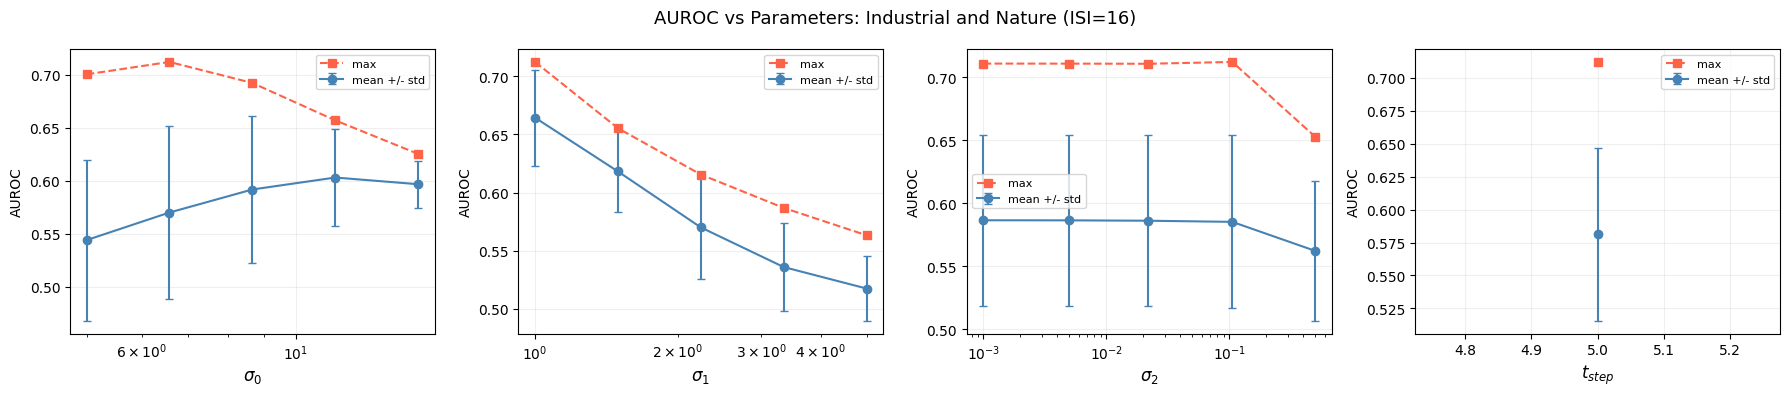

In [34]:
# ── AUROC vs each parameter (marginalizing over the others) ──
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col, label in zip(
    axes,
    ["sigma0", "sigma1", "sigma2", "t_step"],
    ["$\\sigma_0$", "$\\sigma_1$", "$\\sigma_2$", "$t_{step}$"],
):
    grouped = df.groupby(col)["auroc"].agg(["mean", "max", "std"]).reset_index()
    ax.errorbar(grouped[col], grouped["mean"], yerr=grouped["std"],
                fmt='o-', color='steelblue', capsize=3, label='mean +/- std')
    ax.plot(grouped[col], grouped["max"], 's--', color='tomato', label='max')
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel("AUROC")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    if col != "t_step":
        ax.set_xscale("log")

fig.suptitle(f"AUROC vs Parameters: {hr_task_name} (ISI={which_isi})", fontsize=13)
plt.tight_layout()
plt.show()

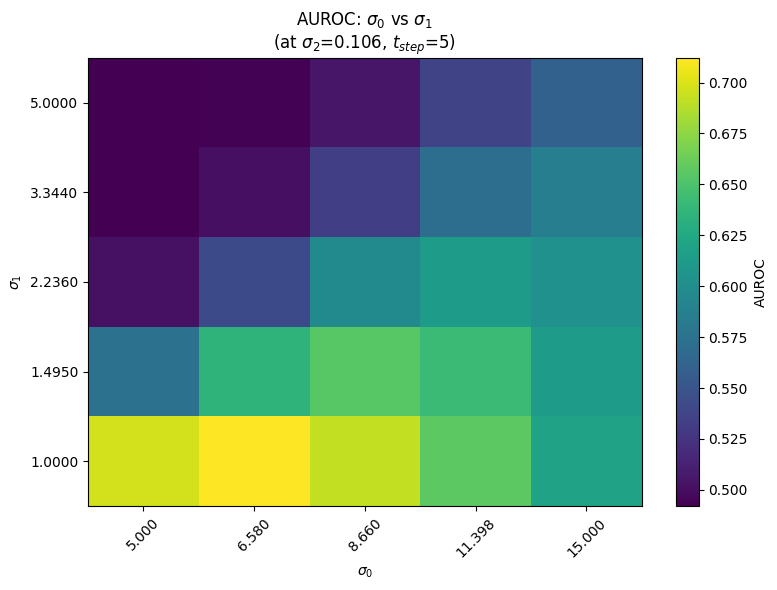

In [35]:
# ── heatmaps: sigma0 vs sigma1, conditioned on best sigma2 and t_step ──
best_s2 = best_params["sigma2"]
best_ts = best_params["t_step"]

subset = df[(df["sigma2"] == best_s2) & (df["t_step"] == best_ts)]

if len(subset) > 1:
    pivot = subset.pivot_table(index="sigma1", columns="sigma0", values="auroc")

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(pivot.values, aspect='auto', origin='lower', cmap='viridis')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{v:.3f}" for v in pivot.columns], rotation=45)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.4f}" for v in pivot.index])
    ax.set_xlabel("$\\sigma_0$")
    ax.set_ylabel("$\\sigma_1$")
    ax.set_title(f"AUROC: $\\sigma_0$ vs $\\sigma_1$\n"
                 f"(at $\\sigma_2$={best_s2}, $t_{{step}}$={best_ts})")
    plt.colorbar(im, ax=ax, label="AUROC")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough data points for heatmap at best sigma2/t_step.")

Re-running best params to show distributions...


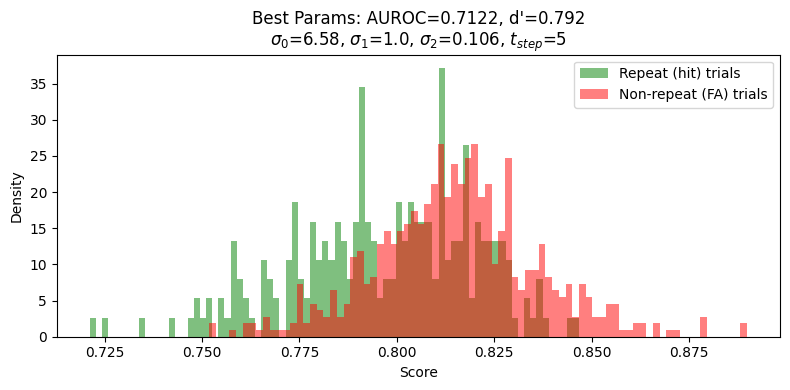

In [36]:
# ── score distributions for the best params ──
print("Re-running best params to show distributions...")

repeat_scores_best     = []
non_repeat_scores_best = []

run_out = run_experiment_scores_itemwise(
    sigma0     = best_params["sigma0"],
    sigma1     = best_params["sigma1"],
    sigma2     = best_params["sigma2"],
    t_step     = best_params["t_step"],
    rate       = None,
    noise_mode = noise_mode,
    metric     = metric,
    X0         = X0,
    name_to_idx = name_to_idx,
    experiment_list = experiment_list,
    seed       = 0,
)

for scores in run_out["item_hits"].values():
    repeat_scores_best.extend(scores)
for scores in run_out["item_fas"].values():
    non_repeat_scores_best.extend(scores)

repeat_scores_best     = np.array(repeat_scores_best)
non_repeat_scores_best = np.array(non_repeat_scores_best)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(repeat_scores_best, bins=80, color='g', alpha=0.5,
        label="Repeat (hit) trials", density=True)
ax.hist(non_repeat_scores_best, bins=80, color='r', alpha=0.5,
        label="Non-repeat (FA) trials", density=True)
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.set_title(
    f"Best Params: AUROC={best_params['auroc']:.4f}, d'={best_params['dprime']:.3f}\n"
    f"$\\sigma_0$={best_params['sigma0']}, $\\sigma_1$={best_params['sigma1']}, "
    f"$\\sigma_2$={best_params['sigma2']}, $t_{{step}}$={best_params['t_step']}"
)
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
# ── final summary ──
print(f"{'='*60}")
print(f"OPTIMIZATION COMPLETE")
print(f"{'='*60}")
print(f"Task:    {hr_task_name} (ISI={which_isi})")
print(f"Encoder: {encoder_name}-{layer_name}")
print(f"Grid:    {total_combos} combos, {len(results)} evaluated")
print(f"")
print(f"Best parameters:")
print(f"  sigma0 = {best_params['sigma0']}")
print(f"  sigma1 = {best_params['sigma1']}")
print(f"  sigma2 = {best_params['sigma2']}")
print(f"  t_step = {best_params['t_step']}")
print(f"")
print(f"  AUROC  = {best_params['auroc']:.4f}")
print(f"  d'     = {best_params['dprime']:.3f}")
print(f"{'='*60}")
print(f"\nTo use in the evaluation notebook:")
print(f"params = dict(")
print(f"    encoder    = \"{encoder_name}\",")
print(f"    layer      = \"{layer_name}\",")
print(f"    sigma0     = {best_params['sigma0']},")
print(f"    sigma1     = {best_params['sigma1']},")
print(f"    sigma2     = {best_params['sigma2']},")
print(f"    t_step     = {best_params['t_step']},")
print(f"    noise_mode = \"{noise_mode}\",")
print(f"    metric     = \"{metric}\",")
print(f"    pc_dims    = {pc_dims},")
print(f")")

OPTIMIZATION COMPLETE
Task:    Industrial and Nature (ISI=16)
Encoder: resnet50-layer4
Grid:    125 combos, 125 evaluated

Best parameters:
  sigma0 = 6.58
  sigma1 = 1.0
  sigma2 = 0.106
  t_step = 5

  AUROC  = 0.7122
  d'     = 0.792

To use in the evaluation notebook:
params = dict(
    encoder    = "resnet50",
    layer      = "layer4",
    sigma0     = 6.58,
    sigma1     = 1.0,
    sigma2     = 0.106,
    t_step     = 5,
    noise_mode = "three-regime",
    metric     = "cosine",
    pc_dims    = None,
)
